# Swapped Wells Investigation

The supervisor flagged in Week 2 that the CoV data may have wells that are physically swapped vs the indexing the pipeline assumes, requiring extra processing. This notebook gives you tools to investigate that visually:

1. **Per-well voltage grid** — V(t) for each of 6 wells × 5 chips. Spot which wells amplify and which don't.
2. **Per-experiment 2D heatmap** — mean linearised V across the 290×204 array, with well bounding boxes overlaid. Shows the spatial layout.
3. **TTP-by-well-by-experiment matrix** — colour-coded heatmap. NTC / non-amplifying wells stand out as a column of "too early" values.
4. **Swap correction config** — once the pattern is identified, a per-experiment well-reorder map that fixes the means.

## Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

NB_DIR = Path.cwd()
for candidate in [NB_DIR, NB_DIR.parent, NB_DIR.parent.parent]:
    titan_pkg = candidate / 'Code' / 'titan-signal-processing'
    if titan_pkg.exists():
        sys.path.insert(0, str(titan_pkg))
        PROJECT_ROOT = candidate
        break
    if (candidate / 'titan').exists() and (candidate / 'analysis').exists():
        sys.path.insert(0, str(candidate))
        PROJECT_ROOT = candidate.parent.parent
        break
else:
    raise RuntimeError('Could not locate titan-signal-processing on disk')

sys.path.insert(0, str(NB_DIR))

import matlab_pipeline as mp
from titan.load_functions import (
    binary_file_read, list_to_numpy_readout, list_to_numpy_gain,
    unwrap_time_vect, find_most_recent_readout, find_corresp_file,
)

DATA_ROOT = PROJECT_ROOT / 'Data' / '24_CoV_Quantification'
EXPERIMENTS_FINAL = {
    '1e5': DATA_ROOT / '1e5' / 'D20240821_E01_C07_F4500KHz_U_1e5',
    '1e6': DATA_ROOT / '1e6' / 'D20240821_E01_C09_F4500KHz_U_1e6',
    '1e7': DATA_ROOT / '1e7' / 'D20240820_E02_C03_F4500KHz_U_1e7',
    '1e8': DATA_ROOT / '1e8' / 'D20240822_E02_C00_F4500KHz_U_1e8',
    '1e9': DATA_ROOT / '1e9' / 'D20240822_E02_C00_F4500KHz_U_1e9',
}
MATLAB_COLORS = ['C0','C3','C1','C4','C2','c']
WELL_POS = ['top-L', 'top-R', 'mid-L', 'mid-R', 'bot-L', 'bot-R']

In [2]:
# Helpers (loader + TTP extractor)
def load_one(exp_path):
    rdt = find_most_recent_readout(exp_path)
    af = find_corresp_file(exp_path, rdt, 'idx_active')
    gf = find_corresp_file(exp_path, rdt, 'gain')
    ts, fr = list_to_numpy_readout(binary_file_read(rdt), n_a_type='v01')
    ts = unwrap_time_vect(ts)
    am = (np.array(binary_file_read(af)[:mp.P_TOTAL])
          .reshape(mp.ROWS, mp.COLS, order='F')
          .reshape(-1, order='C')) == mp.ACTIVE_PIX_MCU_TAG
    g3, _ = list_to_numpy_gain(binary_file_read(gf), n_a_type='v01',
                                exp_path=exp_path, exp_path_readout=rdt)
    return mp.process_experiment_matlab(out_3d=fr, time_sec=ts, gain_3d=g3, idx_active_mcu=am)

def smooth_centered(signal, span):
    if span <= 1: return signal.copy()
    n = len(signal); half = (span - 1) // 2
    out = np.empty(n)
    for i in range(n):
        out[i] = np.mean(signal[max(0,i-half):min(n,i+half+1)])
    return out

def extract_ttp_peak(time_min, signal, x_temp_idx, search_end_idx=None):
    n = len(signal)
    if search_end_idx is None: search_end_idx = max(n - 6, x_temp_idx + 10)
    d_raw = np.diff(signal)
    sig_s = smooth_centered(signal, 100)
    d100 = smooth_centered(np.diff(sig_s), 100)
    s, e = x_temp_idx, min(search_end_idx, len(d100))
    pks_idx, props = find_peaks(d100[s:e], width=1)
    if len(pks_idx) == 0: return np.nan, np.nan
    best = int(np.argmax(d100[s:e][pks_idx] * props['widths']))
    peak_loc = int(pks_idx[best] + s)
    peak_time = float(time_min[peak_loc])
    region = d100[s:peak_loc + 1]
    thr = float(region.min() + 0.4 * (d100[peak_loc] - region.min()))
    below = np.where(d_raw[s:peak_loc + 1] < thr)[0]
    if len(below) == 0: return np.nan, peak_time
    return float(time_min[s + below[-1]]), peak_time

results = {}
for ck, ep in EXPERIMENTS_FINAL.items():
    print(f'Loading {ck}...', end=' ')
    results[ck] = load_one(ep)
    print('done.')
print('All chips loaded.')

Loading 1e5... done.
Loading 1e6... done.
Loading 1e7... done.
Loading 1e8... done.
Loading 1e9... done.
All chips loaded.


## Tool 1 — Per-well voltage grid for one chip

Visualise V(t) for all 6 wells of one chip on a single axis. Wells with real amplification show a clear sigmoid; wells without amplification look flat or drifty.

Change `chip_to_view` to inspect a different concentration.

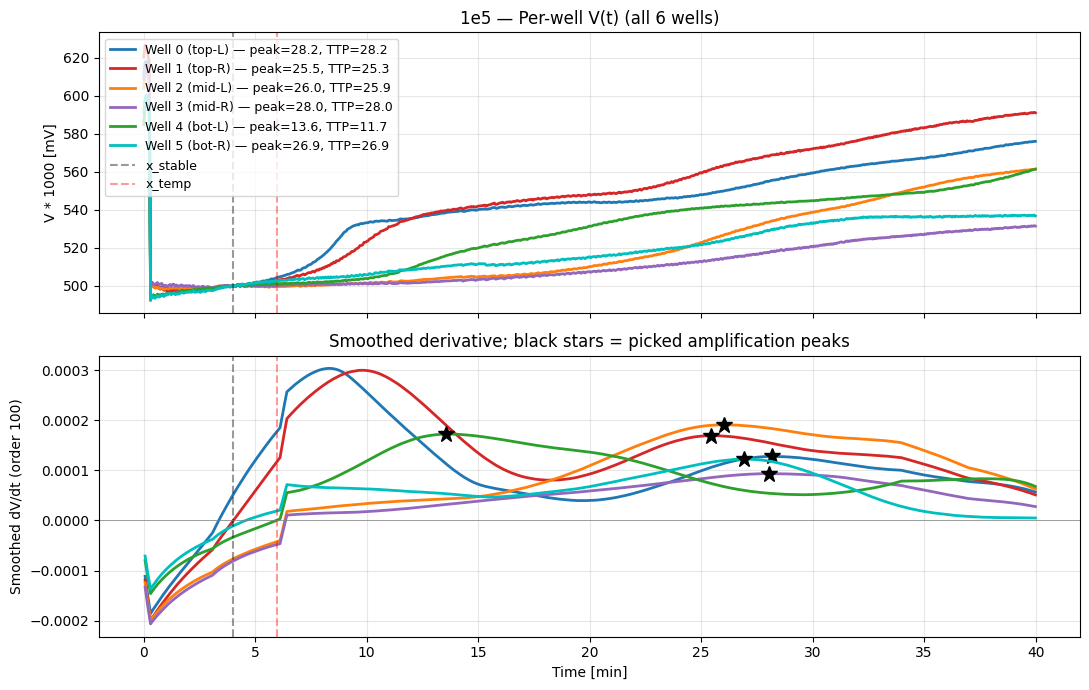

In [15]:
def plot_one_chip_wells(chip_key):
    exp = results[chip_key]
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for i in range(mp.N_WELLS):
        sig = exp.well_traces[i, :]
        ttp, peak = extract_ttp_peak(exp.time_min, sig, exp.x_temp)
        # Voltage trace
        axes[0].plot(exp.time_min, sig * 1e3, linewidth=2, color=MATLAB_COLORS[i],
                     label=f'Well {i} ({WELL_POS[i]}) — peak={peak:.1f}, TTP={ttp:.1f}'
                           if not np.isnan(peak) else f'Well {i} ({WELL_POS[i]}) — no peak found')
        # Smoothed derivative
        sig_s = smooth_centered(sig, 100)
        d100 = smooth_centered(np.diff(sig_s), 100)
        axes[1].plot(exp.time_min[1:], d100, linewidth=2, color=MATLAB_COLORS[i])
        if not np.isnan(peak):
            idx = int(np.searchsorted(exp.time_min[1:], peak))
            if idx < len(d100):
                axes[1].plot(peak, d100[idx], 'k*', markersize=12)
    for ax in axes:
        ax.axvline(exp.time_min[exp.x_stable], color='k', linestyle='--', alpha=0.4, label='x_stable')
        ax.axvline(exp.time_min[exp.x_temp], color='r', linestyle='--', alpha=0.4, label='x_temp')
        ax.grid(alpha=0.3)
    axes[0].set(ylabel='V * 1000 [mV]', title=f'{chip_key} — Per-well V(t) (all 6 wells)')
    axes[0].legend(loc='best', fontsize=9, ncol=1)
    axes[1].set(xlabel='Time [min]', ylabel='Smoothed dV/dt (order 100)',
                title='Smoothed derivative; black stars = picked amplification peaks')
    axes[1].axhline(0, color='gray', linewidth=0.5)
    plt.tight_layout()
    plt.show()

plot_one_chip_wells('1e5')   # try '1e6', '1e7', '1e8', '1e9'

**What to look for in the 1e5 plot above:**
- Wells 2 and 3 should show a clear amplification sigmoid rising at ~25–28 min.
- Wells 0 and 1 are likely flat-ish or drifting — their derivative "peak" at 8–10 min is just the largest bump in noise.
- Well 5 may also show real amplification (it's not in the 'quant' subset 0–3).
- If wells 0 and 1 do look like "no amplification" while wells 2, 3 (and possibly 5) clearly amplify, **physical NTC mapping might be on wells 0 and 1 for this cartridge**.

## Tool 2 — Per-experiment 2D heatmap of array activity

Show the average linearised voltage at a chosen time for each chip, with well boundaries overlaid. Lets you visually verify the cartridge layout and spot any well with anomalously low or high mean signal.

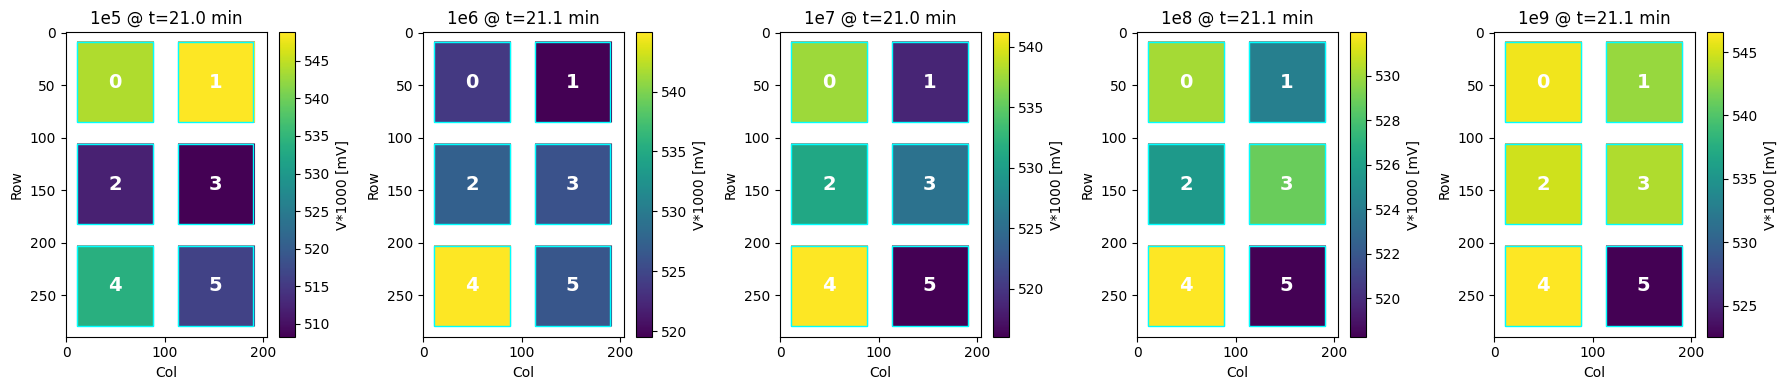

Wells with very different colours from their neighbours might be NTC or failed wells.


In [7]:
def array_heatmap_at(exp, t_min):
    """Reconstruct a 2D image of mean linearised V at one time point.

    Since `exp.well_traces` only stores per-well averages, this is approximate:
    we render each well's bbox filled with its own mean value at time t_min.
    For the original full 290x204 image we would need to re-load the chip
    and run the linearisation - that's covered in tool 3 below if needed.
    """
    img = np.zeros((mp.ROWS, mp.COLS))
    img[:] = np.nan
    t_idx = int(np.searchsorted(exp.time_min, t_min))
    t_idx = min(t_idx, exp.well_traces.shape[1] - 1)
    for i, (rs, re, cs, ce) in enumerate(exp.well_bounds):
        img[rs:re+1, cs:ce+1] = exp.well_traces[i, t_idx]
    return img, t_idx

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, ck in zip(axes, EXPERIMENTS_FINAL):
    exp = results[ck]
    # Pick a time well into amplification region
    t_target = exp.time_min[exp.x_temp] + 15.0
    img, t_idx = array_heatmap_at(exp, t_target)
    im = ax.imshow(img * 1e3, cmap='viridis', aspect='auto')
    ax.set(title=f'{ck} @ t={exp.time_min[t_idx]:.1f} min', xlabel='Col', ylabel='Row')
    for i, (rs, re, cs, ce) in enumerate(exp.well_bounds):
        ax.add_patch(plt.Rectangle((cs, rs), ce-cs, re-rs, fill=False, edgecolor='cyan', linewidth=1))
        ax.text((cs+ce)/2, (rs+re)/2, str(i), color='white', ha='center', va='center', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='V*1000 [mV]')
plt.tight_layout()
plt.show()

print('Wells with very different colours from their neighbours might be NTC or failed wells.')

## Tool 3 — Cross-experiment TTP-per-well heatmap

Build a 5 × 6 matrix of (concentration × well) showing the picked amplification peak time for every well of every chip. Colour-coded with a diverging scale: "too early" wells (< 12 min) are likely catching transient instead of amplification; "too late" wells (> 30 min) are also suspicious.

**The pattern to look for**: if certain wells consistently show "too early" peaks across multiple chips (regardless of what concentration they should be), those wells are likely the physical NTC positions.

In [8]:
# Build the TTP-per-well matrix
all_peaks = {}
all_ttps = {}
for ck, exp in results.items():
    peaks_w, ttps_w = [], []
    for i in range(mp.N_WELLS):
        ttp, peak = extract_ttp_peak(exp.time_min, exp.well_traces[i, :], exp.x_temp)
        peaks_w.append(peak)
        ttps_w.append(ttp)
    all_peaks[ck] = peaks_w
    all_ttps[ck] = ttps_w

peak_matrix = np.array([all_peaks[ck] for ck in EXPERIMENTS_FINAL])  # shape (5, 6)
df_peak = pd.DataFrame(peak_matrix, index=list(EXPERIMENTS_FINAL.keys()),
                       columns=[f'well {i} ({WELL_POS[i]})' for i in range(6)])
print('Amplification peak time (min) per chip per well:')
print(df_peak.round(1))

Amplification peak time (min) per chip per well:
     well 0 (top-L)  well 1 (top-R)  well 2 (mid-L)  well 3 (mid-R)  \
1e5            28.2            25.5            26.0            28.0   
1e6            25.2            25.2            22.8            23.4   
1e7            19.1            22.1            20.3            23.3   
1e8            17.3            19.9            20.0            19.6   
1e9            14.4            16.0            15.5            15.3   

     well 4 (bot-L)  well 5 (bot-R)  
1e5            13.6            26.9  
1e6            16.0             9.7  
1e7            15.3            29.9  
1e8            14.9             6.7  
1e9            13.6            15.2  


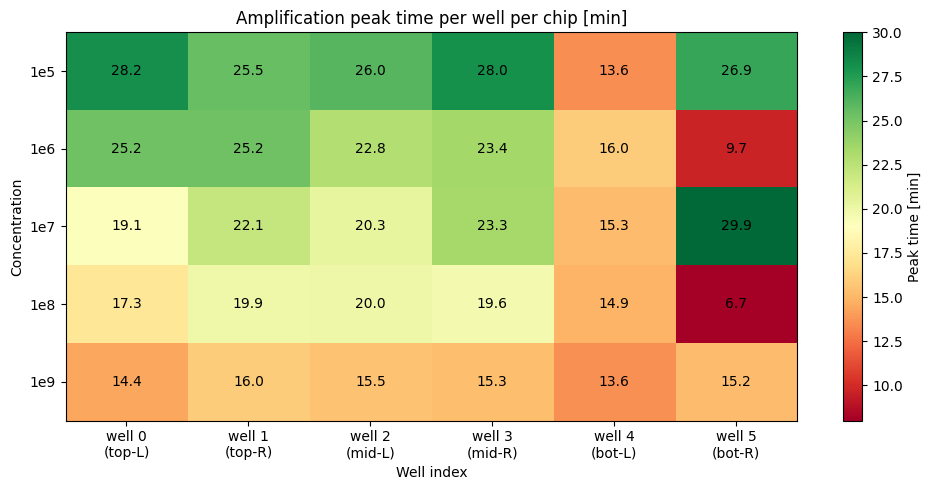


Interpretation guide:
 - Cells with peak < 12 min are likely NOT real amplification (caught residual transient).
 - At a concentration where amplification is loud (1e9), expect all wells to be in 12-17 min.
 - If a particular well-COLUMN consistently shows < 12 min, that physical position is likely NTC.
 - If a particular concentration ROW shows mixed early+late peaks, that is the LoD reality.


In [9]:
# Heatmap with diverging colour scale
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(peak_matrix, cmap='RdYlGn', vmin=8, vmax=30, aspect='auto')
ax.set_xticks(range(6)); ax.set_xticklabels([f'well {i}\n({WELL_POS[i]})' for i in range(6)])
ax.set_yticks(range(5)); ax.set_yticklabels(list(EXPERIMENTS_FINAL.keys()))
ax.set(xlabel='Well index', ylabel='Concentration', title='Amplification peak time per well per chip [min]')
for i in range(5):
    for j in range(6):
        v = peak_matrix[i, j]
        txt = f'{v:.1f}' if not np.isnan(v) else 'NaN'
        ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im, ax=ax, label='Peak time [min]')
plt.tight_layout()
plt.show()

print('\nInterpretation guide:')
print(' - Cells with peak < 12 min are likely NOT real amplification (caught residual transient).')
print(' - At a concentration where amplification is loud (1e9), expect all wells to be in 12-17 min.')
print(' - If a particular well-COLUMN consistently shows < 12 min, that physical position is likely NTC.')
print(' - If a particular concentration ROW shows mixed early+late peaks, that is the LoD reality.')

## Tool 4 — Identify the swap pattern

Below we automatically classify each well as "likely amplifying" or "likely NTC" using a simple heuristic: amplification peak ≥ 12 min AND not within 1 min of `x_temp` (since peaks right at `x_temp` are usually transient artefacts).

Well classified as 'amplifying' (True) vs 'NTC/failed' (False):
     well 0  well 1  well 2  well 3  well 4  well 5
1e5    True    True    True    True    True    True
1e6    True    True    True    True    True   False
1e7    True    True    True    True    True    True
1e8    True    True    True    True    True   False
1e9    True    True    True    True    True    True


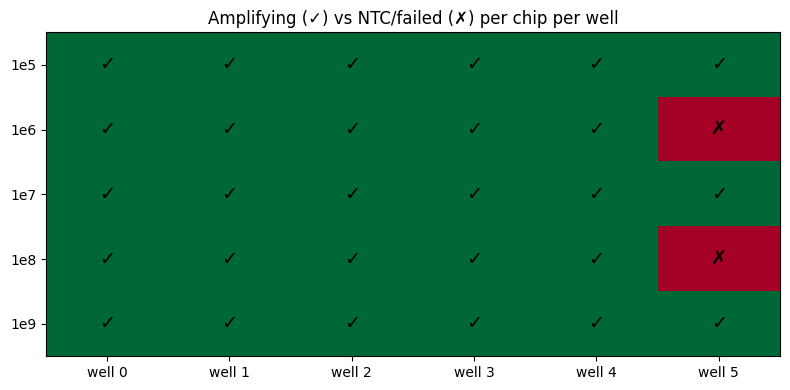

In [11]:
MIN_AMP_PEAK_MIN = 12.0
X_TEMP_BUFFER_MIN = 1.0

is_amp = np.zeros((5, 6), dtype=bool)
for i, ck in enumerate(EXPERIMENTS_FINAL):
    exp = results[ck]
    x_temp_min = exp.time_min[exp.x_temp]
    for j in range(6):
        peak = peak_matrix[i, j]
        if np.isnan(peak):
            is_amp[i, j] = False
        else:
            is_amp[i, j] = (peak >= MIN_AMP_PEAK_MIN) and (peak >= x_temp_min + X_TEMP_BUFFER_MIN)

df_amp = pd.DataFrame(is_amp, index=list(EXPERIMENTS_FINAL),
                       columns=[f'well {i}' for i in range(6)])
print("Well classified as 'amplifying' (True) vs 'NTC/failed' (False):")
print(df_amp)

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(is_amp.astype(int), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(6)); ax.set_xticklabels([f'well {i}' for i in range(6)])
ax.set_yticks(range(5)); ax.set_yticklabels(list(EXPERIMENTS_FINAL))
for i in range(5):
    for j in range(6):
        ax.text(j, i, '✓' if is_amp[i, j] else '✗', ha='center', va='center', fontsize=14)
ax.set(title='Amplifying (✓) vs NTC/failed (✗) per chip per well')
plt.tight_layout()
plt.show()

In [12]:
# Summary: how many amplifying wells per chip, and in which slots?
print('Per-chip summary:')
for i, ck in enumerate(EXPERIMENTS_FINAL):
    amp_wells = [j for j in range(6) if is_amp[i, j]]
    ntc_wells = [j for j in range(6) if not is_amp[i, j]]
    print(f'  {ck}: {len(amp_wells)} amplifying wells = {amp_wells} | NTC/failed = {ntc_wells}')

print('\nPer-WELL-position summary across all 5 chips:')
for j in range(6):
    n_amp = is_amp[:, j].sum()
    print(f'  Well {j} ({WELL_POS[j]}): amplifies in {n_amp}/5 chips '
          + ('  <-- candidate NTC' if n_amp == 0 else ''))

Per-chip summary:
  1e5: 6 amplifying wells = [0, 1, 2, 3, 4, 5] | NTC/failed = []
  1e6: 5 amplifying wells = [0, 1, 2, 3, 4] | NTC/failed = [5]
  1e7: 6 amplifying wells = [0, 1, 2, 3, 4, 5] | NTC/failed = []
  1e8: 5 amplifying wells = [0, 1, 2, 3, 4] | NTC/failed = [5]
  1e9: 6 amplifying wells = [0, 1, 2, 3, 4, 5] | NTC/failed = []

Per-WELL-position summary across all 5 chips:
  Well 0 (top-L): amplifies in 5/5 chips 
  Well 1 (top-R): amplifies in 5/5 chips 
  Well 2 (mid-L): amplifies in 5/5 chips 
  Well 3 (mid-R): amplifies in 5/5 chips 
  Well 4 (bot-L): amplifies in 5/5 chips 
  Well 5 (bot-R): amplifies in 3/5 chips 


## Tool 5 — Apply correction and recompute means

If certain wells are flagged as non-amplifying, we can recompute the per-chip mean using only the amplifying wells. Below we show three options:

1. **Original**: mean over wells 0–3 (the 'quant' subset MATLAB uses)
2. **Median over wells 0–3**: more robust to NTC outliers
3. **Mean over wells flagged as amplifying** (any subset): adaptive per chip

Compare to the supervisor's published `ampl_peaks` mean.

  conc  sup_4rep  my_mean_0-3  my_median_0-3  my_mean_amp_only  \
0  1e5     25.90        26.91          27.02             24.69   
1  1e6     23.50        24.18          24.33             22.54   
2  1e7     20.52        21.21          21.19             21.67   
3  1e8     15.26        19.21          19.76             18.35   
4  1e9     14.78        15.30          15.42             15.01   

   offset_amp_only  
0            -1.21  
1            -0.96  
2             1.15  
3             3.09  
4             0.23  


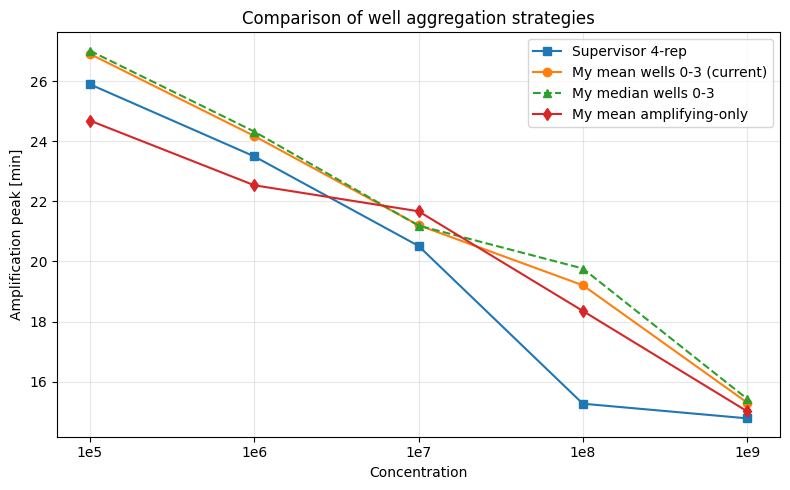

In [13]:
_SUP_PEAK_RAW = np.array([
    [16.1, 14.0, 14.5, 14.5, 15.5],
    [18.7, 10.6, 15.0, 16.75, 14.25],
    [18.47, 21.3, 19.8, 22.5, 14.8],
    [24.1, 24.4, 23.0, 22.5, 13.95],
    [28.7, 29.5, 26.1, 19.3, 15.0],
])
SUP = _SUP_PEAK_RAW[::-1]
sup_4rep = SUP[:, :4].mean(axis=1)

x = np.array([5,6,7,8,9])
rows = []
for i, ck in enumerate(EXPERIMENTS_FINAL):
    peaks = peak_matrix[i]
    mean_03 = np.nanmean(peaks[:4])
    median_03 = np.nanmedian(peaks[:4])
    amp_idx = np.where(is_amp[i])[0]
    mean_amp = np.nanmean(peaks[amp_idx]) if len(amp_idx) > 0 else np.nan
    rows.append((ck, sup_4rep[i], mean_03, median_03, mean_amp,
                 mean_amp - sup_4rep[i] if not np.isnan(mean_amp) else np.nan))

df = pd.DataFrame(rows, columns=['conc', 'sup_4rep', 'my_mean_0-3', 'my_median_0-3',
                                  'my_mean_amp_only', 'offset_amp_only'])
print(df.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, sup_4rep, 's-', label='Supervisor 4-rep')
ax.plot(x, df['my_mean_0-3'], 'o-', label='My mean wells 0-3 (current)')
ax.plot(x, df['my_median_0-3'], '^--', label='My median wells 0-3')
ax.plot(x, df['my_mean_amp_only'], 'd-', label='My mean amplifying-only')
ax.set_xticks(x); ax.set_xticklabels(['1e5','1e6','1e7','1e8','1e9'])
ax.set(xlabel='Concentration', ylabel='Amplification peak [min]',
       title='Comparison of well aggregation strategies')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tool 6 — Manual swap-correction config

Once you know which physical positions are NTC, define a per-chip override map. Below is a starting template — edit `WELL_OVERRIDE` based on what the heatmaps and per-chip plots above tell you.

Format: `{chip_key: list_of_well_indices_to_USE_for_quant}`. Wells not in the list are ignored for the chip-level mean.

If your investigation finds that wells 0 and 1 of the 1e5 chip are the physical NTC positions, you'd write `'1e5': [2, 3, 4, 5]` (or just `[2, 3, 5]` if well 4 is also NTC). Same logic for any other chip with a swap.

In [14]:
WELL_OVERRIDE = {
    # 'chip_key': [well_indices_to_use_for_quant_mean]
    # Examples (uncomment / edit based on your visual inspection above):
    # '1e5': [2, 3, 5],   # if wells 0, 1, 4 are NTC for this chip
    '1e5': [0, 1, 2, 3, 4], 
    '1e6': [0, 1, 2, 3, 4], 
    '1e7': [0, 1, 2, 3, 4], 
    '1e8': [0, 1, 2, 3, 4], 
    '1e9': [0, 1, 2, 3, 4] 
}

# Apply override and re-aggregate
rows = []
for i, ck in enumerate(EXPERIMENTS_FINAL):
    peaks = peak_matrix[i]
    selected = WELL_OVERRIDE.get(ck, [0, 1, 2, 3])
    sel_peaks = [peaks[w] for w in selected if not np.isnan(peaks[w])]
    mean_sel = np.mean(sel_peaks) if sel_peaks else np.nan
    rows.append((ck, ','.join(map(str, selected)), mean_sel, sup_4rep[i],
                 mean_sel - sup_4rep[i] if not np.isnan(mean_sel) else np.nan))

df_override = pd.DataFrame(rows, columns=['conc', 'wells_used', 'my_mean', 'sup_4rep', 'offset'])
print('With WELL_OVERRIDE applied:')
print(df_override.round(2))

With WELL_OVERRIDE applied:
  conc wells_used  my_mean  sup_4rep  offset
0  1e5  0,1,2,3,4    24.24     25.90   -1.66
1  1e6  0,1,2,3,4    22.54     23.50   -0.96
2  1e7  0,1,2,3,4    20.02     20.52   -0.49
3  1e8  0,1,2,3,4    18.35     15.26    3.09
4  1e9  0,1,2,3,4    14.96     14.78    0.19


## Suggested workflow

1. Run the per-chip plot (Tool 1) for each concentration. Note which wells clearly amplify.
2. Look at the cross-experiment heatmap (Tool 3). Are some well-positions consistently early?
3. Update `WELL_OVERRIDE` (Tool 6) with the wells you trust per chip.
4. Re-run the comparison plot in Tool 5.
5. Once `WELL_OVERRIDE` produces a tight slope match to the supervisor, document the pattern (e.g. "chip X has wells 0,1 as NTC due to cartridge orientation") and ask the supervisor to confirm.

## Open question for the supervisor

> *Which physical wells in the cartridge correspond to which Python well index (0–5, row-major from top-left), and is the assignment consistent across all 5 Final-dataset chips, or does it vary per chip? In particular: for the 1e5 Final chip (`D20240821_E01_C07_F4500KHz_U_1e5`), are wells 0 and 1 (top row) the NTC positions, or did those wells fail to amplify for another reason?*